**Purpose:** Additional thesis results and robustness analyses.

**Inputs:** `03_portfolio/dataset.parquet`

**Notes:** paths resolve via `src.config` (run `pip install -e .` from the repo root first).


In [ ]:
from src.config import PROJECT_ROOT


Plotting: MVO-CAPM


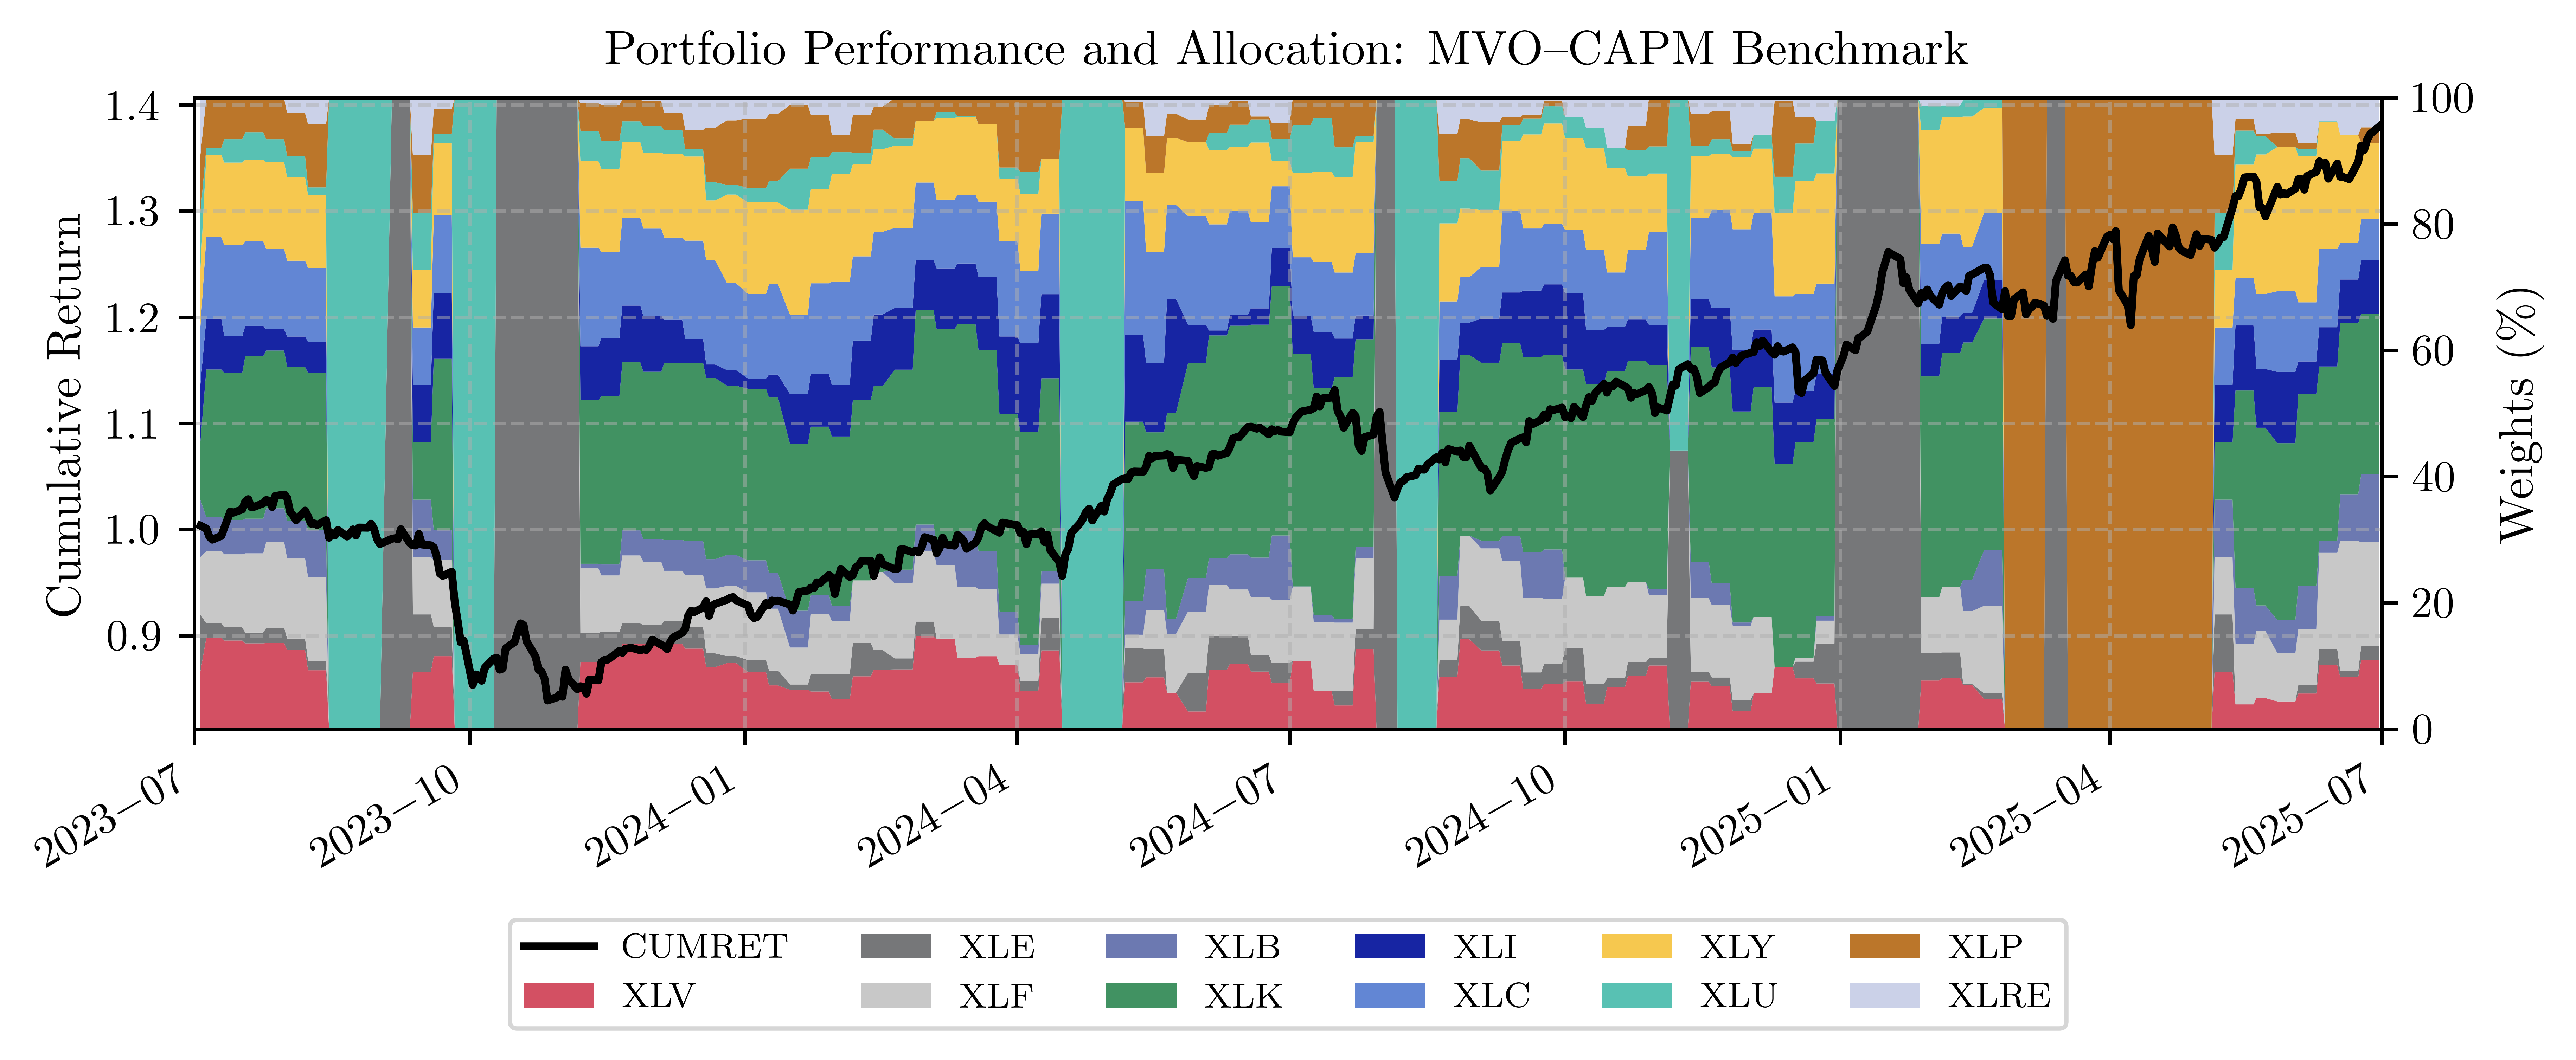

Plotting: EW


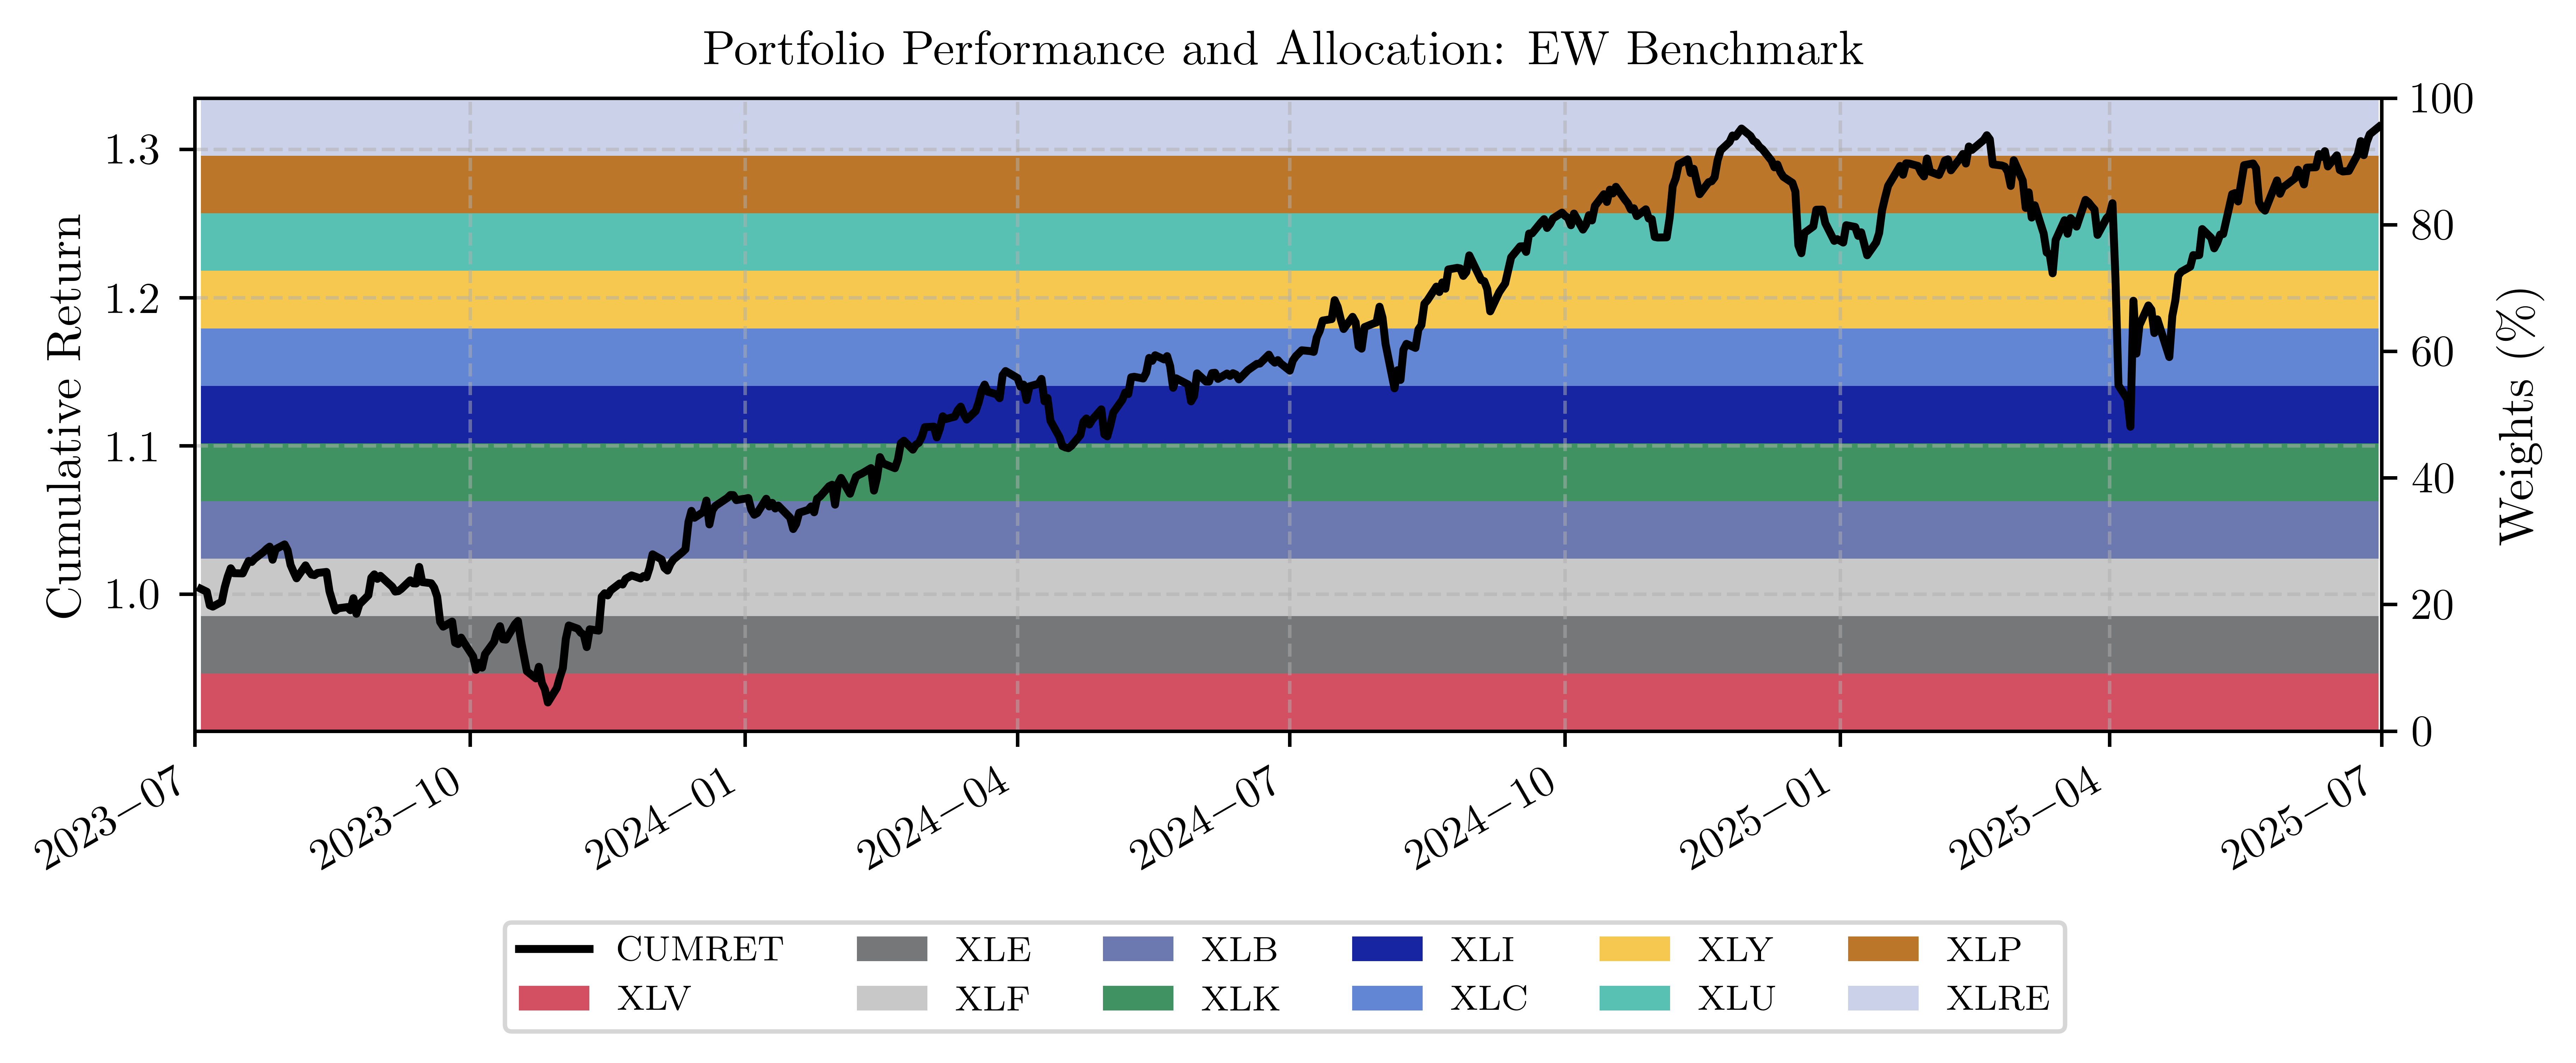

In [2]:
WEIGHTS_files = {
    "LSTMvreturns": {
        "Technical": "weights/LSTMvia-returns_technical_weights.npy",
        "GDELT": "weights/LSTMvia-returns_news_weights.npy",
        "Reddit": "weights/LSTMvia-returns_reddit_weights.npy",
        "GDELT+Reddit": "weights/LSTMvia-returns_reddit+news_weights.npy",
    },
    "LSTMvsharpe": {
        "Technical": "weights/LSTMvia-sharpe_technical_weights.npy",
        "GDELT": "weights/LSTMvia-sharpe_news_weights.npy",
        "Reddit": "weights/LSTMvia-sharpe_reddit_weights.npy",
        "GDELT+Reddit": "weights/LSTMvia-sharpe_reddit+news_weights.npy",
    },
    "DRLPPO": {
        "Technical": "weights/DRLPPO_technical_weights.npy",
        "GDELT": "weights/DRLPPO_news_weights.npy",
        "Reddit": "weights/DRLPPO_reddit_weights.npy",
        "GDELT+Reddit": "weights/DRLPPO_reddit+news_weights.npy",
    },
    "MVO-CAPM": {
        "Benchmark": "weights/MVOCAPM_benchmark_weights.npy",
    },
    "EW": {
        "Benchmark": "weights/EW_benchmark_weights.npy",
    },
}







import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

import numpy as np

# Match your thesis: Latin Modern via LaTeX rendering
mpl.rcParams.update({
    # Use LaTeX for all text rendering
    "text.usetex": True,
    "font.family": "serif",

    # Latin Modern — matches your \usepackage{lmodern}
    "font.serif": ["Latin Modern Roman"],
    "font.sans-serif": ["Latin Modern Sans"],   # matches \sffamily in headings
    "font.monospace": ["Latin Modern Mono"],    # matches your TTT font

    # Match your thesis font size (11pt base)
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # Load lmodern in the LaTeX preamble — critical for matching
    "pgf.preamble": "\n".join([
        r"\usepackage[utf8]{inputenc}",
        r"\usepackage[T1]{fontenc}",
        r"\usepackage{lmodern}",
    ]),

    # Line spacing loosely mirrors your \linespread{1.5}
    "figure.dpi": 900,
})

from src.metrics import PortfolioMetrics
pm = PortfolioMetrics()

DATASET = pd.read_parquet(str(PROJECT_ROOT / "03_portfolio/dataset.parquet"))
ASSETS = ['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']



# ── 1. Custom sector colour palette ──────────────────────────────────────────
SECTOR_COLORS = {
    "XLE":  "#767779",   # Energy           rgb(118, 119, 122)
    "XLB":  "#6C79B1",   # Materials        rgb(108, 121, 177)
    "XLI":  "#1725A3",   # Industrials      rgb(23,  37,  163)
    "XLY":  "#F6C84F",   # Consumer Disc.   rgb(246, 200, 79)
    "XLP":  "#BB762A",   # Consumer Staples rgb(187, 118, 42)
    "XLV":  "#D35063",   # Health Care      rgb(211, 80,  99)
    "XLF":  "#C8C8C8",   # Financials       rgb(200, 200, 200)
    "XLK":  "#419262",   # Technology       rgb(65,  146, 98)
    "XLC":  "#6286D4",   # Comm. Services   rgb(98,  134, 212)
    "XLU":  "#58C1B3",   # Utilities        rgb(88,  193, 179)
    "XLRE": "#CBD1E8",   # Real Estate      rgb(203, 209, 232)
}



def plot_approach_variants(approach_name, variants_dict, ylim_cumret=None, save_path=None, asset_order=None):

    namespaces = {
        "LSTMvreturns": "LSTM--BL",
        "LSTMvsharpe": "LSTM--SR",
        "DRLPPO": "DRL--PPO",
        "MVO-CAPM": "MVO--CAPM",
        "EW": "EW",
    }

    ASSETS_ORDERED = asset_order if asset_order is not None else ASSETS
    reorder_idx = [ASSETS.index(a) for a in ASSETS_ORDERED]

    variant_items = list(variants_dict.items())
    dates_plot = DATASET.index[-500:]

    fig, axes = plt.subplots(1, 1, figsize=(8.27, 11.69*1.05/4*1.1))
    axes = np.atleast_1d(axes)

    for i, (variant_name, weights_file) in enumerate(variant_items):
        weights = np.load(weights_file)
        weights_reordered = weights[:, reorder_idx]
        cumret = pm._cumulative_returns_overtime(weights)

        ax1 = axes[i]
        
        ax1.set_ylabel("Cumulative Return", color="black")
        ax1.tick_params(axis='y', labelcolor="black")
        ax1.grid(True, linestyle="--", alpha=0.5)
        #ax1.set_title(f"{namespaces.get(approach_name, approach_name)} framework, {variant_name} variant", fontsize=10)
        ax1.margins(x=0)
        ax1.set_xlim(pd.Timestamp("2023-07-01"), pd.Timestamp("2025-07-01"))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
        if ylim_cumret is not None:
            ax1.set_ylim(ylim_cumret)

        ax2 = ax1.twinx()

        ax1.set_zorder(2)
        ax2.set_zorder(1)
        ax1.patch.set_visible(False)
        # ── 2. Pass ordered colours to stackplot ─────────────────────────────
        sector_colors_ordered = [SECTOR_COLORS[a] for a in ASSETS_ORDERED]
        ax2.stackplot(
            dates_plot,
            (weights_reordered * 100).T,
            labels=ASSETS_ORDERED,
            colors=sector_colors_ordered,   # <── custom palette
            alpha=1,
        )
        ax2.set_ylim(0, 100)
        ax2.set_ylabel("Weights (\%)")
        ax2.margins(x=0)

        ax1.plot(dates_plot, cumret, color="black", linewidth=1.8, label="CUMRET", zorder=100)

    handles_cumret = [plt.Line2D([0], [0], color="black", linewidth=1.8, label="CUMRET")]
    handles_weights, labels_weights = ax2.get_legend_handles_labels()
    fig.legend(
        handles_cumret + handles_weights,
        ["CUMRET"] + labels_weights,
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(0.5, -0.05),
        frameon=True,
        fontsize=8,
    )

    # ── 3. Tighter gap between suptitle and first subplot ────────────────────
    plt.suptitle(
        f"Portfolio Performance and Allocation: {namespaces.get(approach_name, approach_name)} Benchmark",
        fontsize=11,
        y=0.9,           # was 1.005 — pull it down slightly
    )
    plt.tight_layout(rect=[0, 0.06, 1, 0.99])  # was [0, 0.06, 1, 1] — shrink top room

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# Define your desired display order here — reorder freely, must be a permutation of ASSETS
#ASSETS_DISPLAY_ORDER = ['XLE', 'XLB', 'XLI', 'XLY', 'XLP', 'XLV', 'XLF', 'XLK', 'XLC', 'XLU', 'XLRE']

ASSETS_DISPLAY_ORDER = ['XLV', 'XLE', 'XLF', 'XLB', 'XLK', 'XLI', 'XLC', 'XLY', 'XLU', 'XLP', 'XLRE']


SKIP = {"MVO-CAPM", "EW"}  # these are plotted separately / not in 2x2

for approach_name, variants in WEIGHTS_files.items():
    if approach_name not in SKIP:
        continue  # skip benchmarks

    print(f"Plotting: {approach_name}")

    ylim = None

    plot_approach_variants(
        approach_name=approach_name,
        variants_dict=variants,
        ylim_cumret=ylim,
        asset_order=ASSETS_DISPLAY_ORDER,
        #save_path=None,
        save_path=f"{PROJECT_ROOT}/thesis/figs/CUMRET_WEIGHTS_{approach_name}.png",
    )
